<a href="https://colab.research.google.com/github/Zeenah-Yusuf/Deeptech-Computer-Vision/blob/main/deeptech_task_1_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Soccer Football Player Detection, Tracking and Clustering

In [ ]:
# Activating CUDA
import torch
torch.cuda.is_available()

True

In [ ]:
# Installing Libraries
!pip install ultralytics numpy opencv-python scikit-learn supervision

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.9/41.9 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 67.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 217.4/217.4 kB 24.3 MB/s eta 0:00:00


In [11]:
import cv2
import numpy as np
from sklearn.cluster import KMeans
from ultralytics import YOLO
from google.colab.patches import cv2_imshow
from google.colab import files
import os

VIDEO_PATH = r"/content/football_video2.mp4"
CONF_THRESHOLD = 0.25
CLUSTER_FRAMES = 100
MAX_LOST = 50

class FootballTracker:
    def __init__(self, video_path):
        self.cap = cv2.VideoCapture(video_path)
        self.width = int(self.cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        self.height = int(self.cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        self.fps = int(self.cap.get(cv2.CAP_PROP_FPS))

        self.out = cv2.VideoWriter(
            "Tracked_output1.mp4",
            cv2.VideoWriter_fourcc(*'mp4v'),
            self.fps,
            (self.width, self.height)
        )

        self.model = YOLO("yolov8m.pt")

        self.tracks = {}
        self.track_colors = {}
        self.track_to_perm = {}
        self.perm_info = {}
        self.counts = {}
        self.frame_num = 0
        self.clustering_done = False
        self.team_cluster_map = {}

    def extract_jersey_color(self, img):
        if img is None or img.size == 0:
            return None
        h, w = img.shape[:2]
        if h == 0 or w == 0:
            return None

        upper = img[:h//2, :]
        if upper is None or upper.size == 0:
            return None

        try:
            pixels = upper.reshape(-1, 3)
        except ValueError:
            return None

        if pixels.shape[0] < 2:
            return None

        try:
            kmeans = KMeans(n_clusters=5, random_state=42, n_init=5)
            labels = kmeans.fit_predict(pixels)
            centers = kmeans.cluster_centers_

            counts = np.bincount(labels)
            dominant_cluster_idx = np.argmax(counts)
            dominant_color = centers[dominant_cluster_idx]

            return tuple(int(c) for c in dominant_color)
        except Exception as e:
            return None

    def get_color_category(self, bgr_color):
        hsv = cv2.cvtColor(np.uint8([[bgr_color]]), cv2.COLOR_BGR2HSV)[0][0]
        h, s, v = hsv

        if (h <= 15 or h >= 165) and s >= 40 and v >= 40:
            return "red"
        elif (h >= 100 and h <= 140) and s >= 40 and v >= 40:
            return "blue"
        elif s <= 25 and v >= 180:
            return "white"
        elif v <= 50:
            return "black"
        else:
            return "other"

    def average_color(self, samples):
        valid_samples = [s for s in samples if s is not None]
        if not valid_samples:
            return (0,0,0)
        return tuple(np.mean(valid_samples, axis=0).astype(int))

    def process_frame_stage1(self, frame):
        self.frame_num += 1
        results = self.model.track(frame, persist=True, conf=CONF_THRESHOLD, iou=0.5, verbose=False)[0]

        if results.boxes is not None and results.boxes.id is not None:
            boxes = results.boxes.xyxy.cpu().numpy().astype(int)
            track_ids = results.boxes.id.cpu().numpy().astype(int)
            classes = results.boxes.cls.cpu().numpy().astype(int)

            for box, tid, cls in zip(boxes, track_ids, classes):
                if cls != 0:
                    continue
                x1, y1, x2, y2 = box
                crop = frame[y1:y2, x1:x2]
                color = self.extract_jersey_color(crop)
                if tid not in self.tracks:
                    self.tracks[tid] = {"color_samples": [], "last_seen": self.frame_num}
                if color is not None:
                    self.tracks[tid]["color_samples"].append(color)
                self.tracks[tid]["last_seen"] = self.frame_num
                cv2.rectangle(frame, (x1,y1), (x2,y2), (255,255,255), 2)
                cv2.putText(frame, f"T{tid}", (x1,y1-5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,0,0), 2)
        return frame

    def cluster_teams(self):
        track_ids_for_clustering, colors_for_clustering = [], []
        for tid, track in self.tracks.items():
            if len(track["color_samples"]) >= 5:
                avg_col = self.average_color(track["color_samples"])
                if avg_col != (0,0,0):
                    track_ids_for_clustering.append(tid)
                    colors_for_clustering.append(avg_col)
                    self.track_colors[tid] = avg_col

        if len(track_ids_for_clustering) < 4:
            print("Not enough samples to cluster teams effectively.")
            return False

        kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
        cluster_labels = kmeans.fit_predict(colors_for_clustering)
        cluster_centers = kmeans.cluster_centers_

        assigned_names = []
        for i, center_bgr in enumerate(cluster_centers):
            base_name = self.get_color_category(center_bgr)
            final_name = base_name
            suffix = 1
            while final_name in assigned_names:
                final_name = f"{base_name}_{suffix}"
                suffix += 1
            assigned_names.append(final_name)
            self.team_cluster_map[i] = {"name": final_name, "color": tuple(int(c) for c in center_bgr)}
            self.counts[final_name] = 0

        for i, tid in enumerate(track_ids_for_clustering):
            cluster_label = cluster_labels[i]
            team_info = self.team_cluster_map[cluster_label]
            team_name = team_info["name"]

            self.counts[team_name] += 1
            perm_id = f"{team_name[0].upper()}{self.counts[team_name]}"
            self.track_to_perm[tid] = perm_id
            self.perm_info[perm_id] = {"color": team_info["color"], "team_name": team_name}
            print(f"Assigned {perm_id} ({team_name}) to track {tid}")

        self.clustering_done = True
        return True

    def process_frame_stage2(self, frame):
        self.frame_num += 1
        results = self.model.track(frame, persist=True, conf=CONF_THRESHOLD, iou=0.5, verbose=False)[0]

        if results.boxes is not None and results.boxes.id is not None:
            boxes = results.boxes.xyxy.cpu().numpy().astype(int)
            track_ids = results.boxes.id.cpu().numpy().astype(int)
            classes = results.boxes.cls.cpu().numpy().astype(int)

            for box, tid, cls in zip(boxes, track_ids, classes):
                if cls != 0:
                    continue
                x1, y1, x2, y2 = box

                color_to_draw = (0, 255, 0)
                perm_id = "UNKNOWN"

                if tid in self.track_to_perm:
                    perm_id = self.track_to_perm[tid]
                    color_to_draw = self.perm_info[perm_id]["color"]
                else:
                    crop = frame[y1:y2, x1:x2]
                    extracted_color = self.extract_jersey_color(crop)
                    if extracted_color is None:
                        color_to_draw = (128, 128, 128)
                        perm_id = "NEW_UNKWN"
                    else:
                        best_team_label = -1
                        min_dist = float('inf')
                        for cluster_label, team_info in self.team_cluster_map.items():
                            team_avg_bgr = np.array(team_info["color"])
                            dist = np.linalg.norm(np.array(extracted_color) - team_avg_bgr)
                            if dist < min_dist:
                                min_dist = dist
                                best_team_label = cluster_label

                        if best_team_label != -1:
                            team_info = self.team_cluster_map[best_team_label]
                            team_name = team_info["name"]
                            self.counts[team_name] = self.counts.get(team_name, 0) + 1
                            perm_id = f"{team_name[0].upper()}{self.counts[team_name]}"
                            self.track_to_perm[tid] = perm_id
                            self.perm_info[perm_id] = {"color": team_info["color"], "team_name": team_name}
                            color_to_draw = team_info["color"]
                        else:
                            color_to_draw = (128, 128, 128)
                            perm_id = "NEW_UNKWN"

                try:
                    final_color = tuple(int(c) for c in color_to_draw)
                    cv2.rectangle(frame, (x1, y1), (x2, y2), final_color, 3)
                    cv2.putText(frame, perm_id, (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,0,0), 2)
                except Exception as e:
                    print(f"Error drawing rectangle for perm_id {perm_id}: {e}")
                    print(f"Problematic color value: {color_to_draw}, type: {type(color_to_draw)}")
                    cv2.rectangle(frame, (x1, y1), (x2, y2), (255, 0, 255), 3)
                    cv2.putText(frame, f"ERR_{perm_id}", (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,0,0), 2)

        return frame

    def run(self):
        print(f"Starting Stage 1: Collecting {CLUSTER_FRAMES} frames for clustering.")

        while self.frame_num < CLUSTER_FRAMES:
            ret, frame = self.cap.read()
            if not ret:
                print("End of video reached during Stage 1.")
                break
            processed = self.process_frame_stage1(frame)
            self.out.write(processed)
            if self.frame_num % 50 == 0:
                print(f"Processed {self.frame_num}/{CLUSTER_FRAMES} frames.")

        self.cap.set(cv2.CAP_PROP_POS_FRAMES, 0)
        self.frame_num = 0

        print("Starting Team Clustering...")
        if not self.cluster_teams():
            print("Clustering failed or not enough samples. Exiting.")
            self.cap.release()
            self.out.release()
            return
        print("Team Clustering complete.")

        print("Starting Stage 2: Applying permanent IDs to all frames.")
        while True:
            ret, frame = self.cap.read()
            if not ret:
                print("End of video reached during Stage 2.")
                break
            processed = self.process_frame_stage2(frame)
            self.out.write(processed)

        self.cap.release()
        self.out.release()
        print("Tracking complete. Output saved to Tracked_output1.mp4")

        from google.colab import files
        files.download("Tracked_output1.mp4")


if __name__ == "__main__":
    tracker = FootballTracker(VIDEO_PATH)
    tracker.run()

Starting Stage 1: Collecting 100 frames for clustering.
Processed 50/100 frames.
Processed 100/100 frames.
Starting Team Clustering...
Assigned O1 (other_1) to track 1
Assigned O2 (other_1) to track 2
Assigned O3 (other_1) to track 3
Assigned O4 (other_1) to track 4
Assigned O5 (other_1) to track 5
Assigned O6 (other_1) to track 6
Assigned O7 (other_1) to track 7
Assigned O8 (other_1) to track 8
Assigned O9 (other_1) to track 9
Assigned O10 (other_1) to track 10
Assigned O11 (other_1) to track 11
Assigned O12 (other_1) to track 12
Assigned O13 (other_1) to track 13
Assigned O14 (other_1) to track 14
Assigned O1 (other) to track 17
Assigned O2 (other) to track 22
Assigned O15 (other_1) to track 23
Assigned O16 (other_1) to track 31
Assigned O3 (other) to track 40
Assigned O17 (other_1) to track 42
Team Clustering complete.
Starting Stage 2: Applying permanent IDs to all frames.
End of video reached during Stage 2.
Tracking complete. Output saved to Tracked_output1.mp4


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

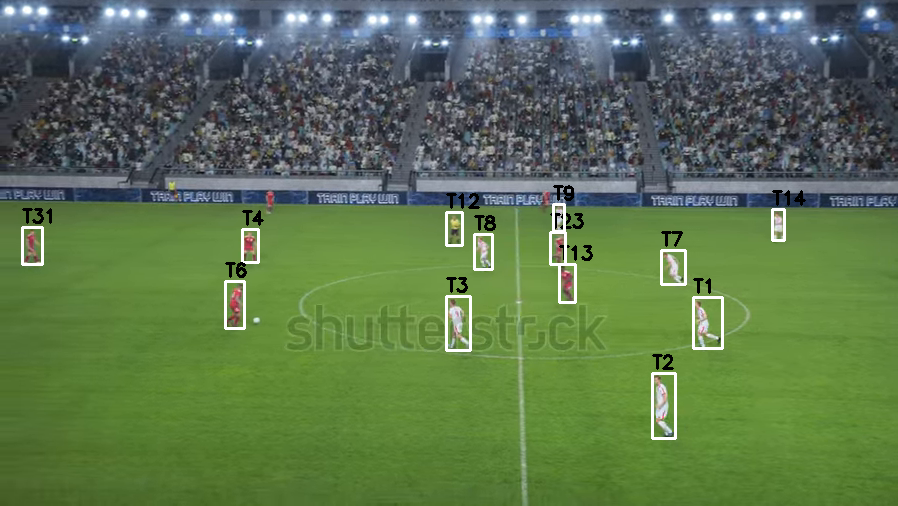

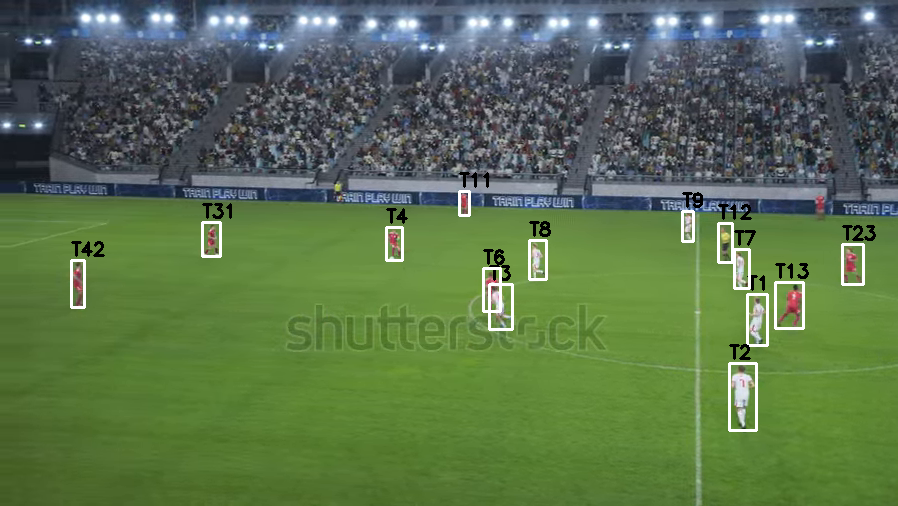

Assigned W1 to track 1
Assigned W2 to track 2
Assigned W3 to track 3
Assigned R1 to track 4
Assigned W4 to track 5
Assigned R2 to track 6
Assigned W5 to track 7
Assigned W6 to track 8
Assigned W7 to track 9
Assigned W8 to track 10
Assigned R3 to track 11
Assigned W9 to track 12
Assigned R4 to track 13
Assigned R5 to track 14
Assigned W10 to track 17
Assigned W11 to track 22
Assigned R6 to track 23
Assigned R7 to track 31
Assigned R8 to track 40
Assigned R9 to track 42
New white player assigned: W12
New white player assigned: W13
New white player assigned: W14
New white player assigned: W15
New white player assigned: W16
New white player assigned: W17
New white player assigned: W18
New white player assigned: W19
New white player assigned: W20
New white player assigned: W21
New white player assigned: W22
New white player assigned: W23
New white player assigned: W24
New white player assigned: W25
New white player assigned: W26
New white player assigned: W27
New white player assigned: W28


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Importing Libraries
import cv2
import numpy as np
from sklearn.cluster import KMeans
from ultralytics import YOLO
from google.colab.patches import cv2_imshow
from google.colab import files
import os

# Path to your football video
VIDEO_PATH = r"/content/football_video2.mp4"

# Detection confidence threshold
CONF_THRESHOLD = 0.25

CLUSTER_FRAMES = 100

class FootballTracker:
    def __init__(self, video_path):
        # Load video
        self.cap = cv2.VideoCapture(video_path)
        self.width = int(self.cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        self.height = int(self.cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        self.fps = int(self.cap.get(cv2.CAP_PROP_FPS))

        # Output video
        self.out = cv2.VideoWriter(
            "Tracked_output2.mp4",
            cv2.VideoWriter_fourcc(*'mp4v'),
            self.fps,
            (self.width, self.height)
        )

        # Load YOLO model
        self.model = YOLO("yolov8m.pt")

        # Tracking data
        self.tracks = {}
        self.track_colors = {}
        self.track_to_perm = {}
        self.perm_info = {}
        self.counts = {"red":0, "white":0}
        self.frame_num = 0
        self.clustering_done = False

    def extract_jersey_color(self, img):
        if img is None or img.size == 0:
            return None
        h, w = img.shape[:2]
        upper = img[:h//2, :]
        pixels = upper.reshape(-1, 3)
        kmeans = KMeans(n_clusters=2, random_state=42, n_init=5)
        labels = kmeans.fit_predict(pixels)
        centers = kmeans.cluster_centers_
        # Picking the more saturated color
        best = centers[0]
        return tuple(int(c) for c in best)

    def average_color(self, samples):
        return tuple(np.mean(samples, axis=0).astype(int))

    def process_frame_stage1(self, frame):
        self.frame_num += 1
        results = self.model.track(frame, persist=True, conf=CONF_THRESHOLD, iou=0.5, verbose=False)[0]

        if results.boxes is not None and results.boxes.id is not None:
            boxes = results.boxes.xyxy.cpu().numpy().astype(int)
            track_ids = results.boxes.id.cpu().numpy().astype(int)
            classes = results.boxes.cls.cpu().numpy().astype(int)

            for box, tid, cls in zip(boxes, track_ids, classes):
                if cls != 0:  # only persons
                    continue
                x1, y1, x2, y2 = box
                crop = frame[y1:y2, x1:x2]
                color = self.extract_jersey_color(crop)
                if tid not in self.tracks:
                    self.tracks[tid] = {"color_samples": [], "last_seen": self.frame_num}
                self.tracks[tid]["color_samples"].append(color)
                self.tracks[tid]["last_seen"] = self.frame_num
                cv2.rectangle(frame, (x1,y1), (x2,y2), (255,255,255), 2)
                cv2.putText(frame, f"T{tid}", (x1,y1-5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,0,0), 2)

        return frame

    def cluster_teams(self):
        track_ids, colors = [], []
        for tid, track in self.tracks.items():
            if len(track["color_samples"]) >= 5:
                avg_col = self.average_color(track["color_samples"])
                track_ids.append(tid)
                colors.append(avg_col)
                self.track_colors[tid] = avg_col

        if len(track_ids) < 4:
            print("Not enough samples to cluster.")
            return False

        kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
        labels = kmeans.fit_predict(colors)

        # Assign team IDs
        for tid, label in zip(track_ids, labels):
            team = "red" if label == 0 else "white"
            self.counts[team] += 1
            perm_id = f"{team[0].upper()}{self.counts[team]}"
            self.track_to_perm[tid] = perm_id
            self.perm_info[perm_id] = {"color": tuple(int(c) for c in self.track_colors[tid])}
            print(f"Assigned {perm_id} to track {tid}")

        self.clustering_done = True
        return True

    def process_frame_stage2(self, frame):
        self.frame_num += 1
        results = self.model.track(frame, persist=True, conf=CONF_THRESHOLD, iou=0.5, verbose=False)[0]

        if results.boxes is not None and results.boxes.id is not None:
            boxes = results.boxes.xyxy.cpu().numpy().astype(int)
            track_ids = results.boxes.id.cpu().numpy().astype(int)
            classes = results.boxes.cls.cpu().numpy().astype(int)

            for box, tid, cls in zip(boxes, track_ids, classes):
                if cls != 0:
                    continue
                x1, y1, x2, y2 = box

                # If this track already has a permanent ID, just draw it
                if tid in self.track_to_perm:
                    perm_id = self.track_to_perm[tid]
                    color = self.perm_info[perm_id]["color"]
                else:
                    # New track after clustering – assign to nearest team
                    crop = frame[y1:y2, x1:x2]
                    color = self.extract_jersey_color(crop)
                    if color is None:
                        continue

                    # Compare with existing team colors
                    best_team = None
                    best_dist = float("inf")
                    for perm_id, info in self.perm_info.items():
                        dist = np.linalg.norm(np.array(color) - np.array(info["color"]))
                        if dist < best_dist:
                            best_dist = dist
                            best_team = "red" if perm_id.startswith("B") else "white"

                    if best_team:
                        self.counts[best_team] += 1
                        perm_id = f"{best_team[0].upper()}{self.counts[best_team]}"
                        self.track_to_perm[tid] = perm_id
                        self.perm_info[perm_id] = {"color": color}
                        print(f"New {best_team} player assigned: {perm_id}")
                    else:
                        continue

                # Draw bounding box
                cv2.rectangle(frame, (x1, y1), (x2, y2), color, 3)
                cv2.putText(frame, perm_id, (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,0,0), 2)

        return frame


    def run(self):
        # Stage 1: collect samples
        while self.frame_num < CLUSTER_FRAMES:
            ret, frame = self.cap.read()
            if not ret: break
            processed = self.process_frame_stage1(frame)
            self.out.write(processed)
            if self.frame_num % 50 == 0:
                cv2_imshow(processed)


        # Cluster teams
        if not self.cluster_teams():
            print("Clustering failed.")
            return

        # Stage 2: permanent IDs
        while True:
            ret, frame = self.cap.read()
            if not ret: break
            processed = self.process_frame_stage2(frame)
            self.out.write(processed)

        self.cap.release()
        self.out.release()
        print("Tracking complete. Output saved to Tracked_output2.mp4")

        from google.colab import files
        files.download("Tracked_output2.mp4")


# Run tracker
if __name__ == "__main__":
    tracker = FootballTracker(VIDEO_PATH)
    tracker.run()
